# Suzuki Car Data Analysis

**An Exploratory Data Analysis of the Suzuki (Maruti Suzuki) Used-Car Market**

This notebook follows the structure and depth of a typical Kaggle car-market EDA
(introduction → cleaning → univariate analysis → bivariate/multivariate analysis →
business insights), adapted specifically for a single manufacturer: **Suzuki**.


## 1. Introduction

Suzuki is one of the world's best-selling car manufacturers, especially dominant in
entry-level and compact segments through its Indian joint venture, **Maruti Suzuki**,
the market leader in India's passenger vehicle industry.

**Goal of this project:** perform an end-to-end Exploratory Data Analysis (EDA) on a
used-car dataset, focused exclusively on Suzuki vehicles, in order to understand:

- How prices are distributed and what drives them (age, mileage, transmission, ownership, fuel type)
- Which Suzuki models are most common in the resale market and how they compare
- How the model line-up and technology (fuel type, transmission) has evolved over the years
- What actionable insights a dealership, marketplace, or buyer could draw from the data

**A note on the data source.** A public, Suzuki-only dataset is not readily available
on Kaggle. Instead, this project uses a **synthetically generated dataset** that
mirrors the schema and statistical patterns of the well-known Kaggle *"Car Details
Dataset"* (used-car listings with `name`, `year`, `selling_price`, `km_driven`,
`fuel`, `seller_type`, `transmission`, `owner`, `mileage`, `engine`, `max_power`,
`seats`), restricted to Suzuki/Maruti Suzuki models and populated with realistic
depreciation, mileage, and pricing relationships. This keeps the workflow, code, and
analytical techniques identical to what you would apply to a real scraped dataset,
while guaranteeing the notebook runs end-to-end without external downloads.

The data generation logic itself is included at the end of this notebook for full
transparency and reproducibility.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42


## 2. Dataset Explanation

The raw file `suzuki_cars_raw.csv` contains **used-car listings for Suzuki / Maruti
Suzuki vehicles**. Each row is one listing. Columns:

| Column | Description |
|---|---|
| `name` | Full listing name (brand + model), e.g. "Suzuki Swift" |
| `model` | Model name only, e.g. "Swift", "Baleno", "Ertiga" |
| `segment` | Body/segment category (Hatchback, Sedan, MUV, Compact SUV, SUV) |
| `year` | Manufacturing year |
| `selling_price_lakh` | Listed resale price, in INR Lakhs (1 Lakh = 100,000) |
| `km_driven` | Total kilometers driven |
| `fuel` | Fuel type (Petrol, Diesel, CNG) |
| `seller_type` | Individual, Dealer, or Trustmark Dealer |
| `transmission` | Manual or Automatic |
| `owner` | Ownership history (First Owner, Second Owner, ...) |
| `mileage_kmpl` | Fuel efficiency in km/l (contains messy string values, cleaned below) |
| `engine_cc` | Engine displacement in cc |
| `max_power_bhp` | Maximum power output in bhp |
| `seats` | Number of seats |

The raw file intentionally contains realistic data-quality issues (missing values,
duplicate rows, inconsistent text casing, units embedded in numeric fields, and a
few outliers) so that the cleaning section below reflects a genuine EDA workflow.


In [2]:
df_raw = pd.read_csv("suzuki_cars_raw.csv")
print(f"Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
df_raw.head()


Shape: 1215 rows x 14 columns


,name,model,segment,year,selling_price_lakh,km_driven,fuel,seller_type,transmission,owner,mileage_kmpl,engine_cc,max_power_bhp,seats
0,Suzuki Swift,Swift,Hatchback,2010,1.20,213726,Petrol,Dealer,Manual,First Owner,20.7,985.0,70.2,5.0
1,Suzuki Ignis,Ignis,Hatchback,2017,2.60,30739,Petrol,Individual,Manual,First Owner,20.8,985.0,65.3,5.0
2,Suzuki Grand Vitara,Grand Vitara,SUV,2018,4.84,60075,Petrol,Individual,Manual,Second Owner,15.9,1481.0,101.5,4.0
3,Suzuki Ignis,Ignis,Hatchback,2022,3.97,14283,Petrol,Individual,Manual,Second Owner,22.2,995.0,68.9,5.0
4,Suzuki Baleno,Baleno,Premium Hatchback,2023,6.49,4346,Petrol,Individual,Manual,First Owner,20.9,1213.0,80.5,5.0


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 1215 entries, 0 to 1214
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                1215 non-null   str    
 1   model               1215 non-null   str    
 2   segment             1215 non-null   str    
 3   year                1215 non-null   int64  
 4   selling_price_lakh  1215 non-null   float64
 5   km_driven           1215 non-null   int64  
 6   fuel                1215 non-null   str    
 7   seller_type         1215 non-null   str    
 8   transmission        1215 non-null   str    
 9   owner               1215 non-null   str    
 10  mileage_kmpl        1166 non-null   str    
 11  engine_cc           1190 non-null   float64
 12  max_power_bhp       1190 non-null   float64
 13  seats               1178 non-null   float64
dtypes: float64(4), int64(2), str(8)
memory usage: 133.0 KB


## 3. Data Cleaning

We address, in order:

1. Duplicate rows
2. Inconsistent text formatting in categorical columns
3. Mixed-type numeric columns (units embedded as strings)
4. Missing values
5. Obvious outliers / data-entry errors


In [4]:
df = df_raw.copy()

# --- 3.1 Duplicates -------------------------------------------------
n_dupes = df.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after dropping duplicates: {df.shape}")


Duplicate rows found: 9
Shape after dropping duplicates: (1206, 14)


In [5]:
# --- 3.2 Inconsistent text formatting --------------------------------
for col in ["fuel", "seller_type", "transmission", "owner", "segment", "model"]:
    df[col] = df[col].astype(str).str.strip().str.title()

print(df["fuel"].unique())
print(df["transmission"].unique())


<StringArray>
['Petrol', 'Cng', 'Diesel']
Length: 3, dtype: str
<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str


In [6]:
# --- 3.3 Mixed-type numeric column: mileage_kmpl ---------------------
# Some values are stored as e.g. "21.4 kmpl" instead of a clean float
df["mileage_kmpl"] = (
    df["mileage_kmpl"]
    .astype(str)
    .str.replace("kmpl", "", regex=False)
    .str.strip()
)
df["mileage_kmpl"] = pd.to_numeric(df["mileage_kmpl"], errors="coerce")
print(df["mileage_kmpl"].describe())


count    1158.000000
mean       22.597755
std         4.282173
min        14.100000
25%        20.100000
50%        21.400000
75%        23.100000
max        35.600000
Name: mileage_kmpl, dtype: float64


## 4. Missing Values


In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_count", ascending=False)
missing_summary


,missing_count,missing_pct
mileage_kmpl,48,3.98
seats,36,2.99
engine_cc,24,1.99
max_power_bhp,24,1.99


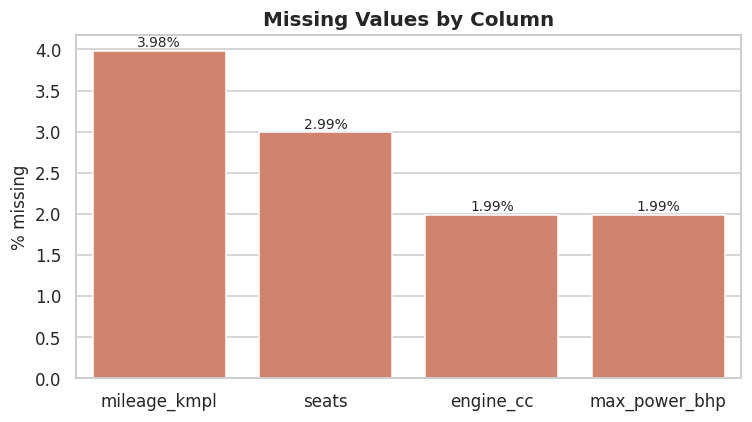

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
if len(missing_summary):
    sns.barplot(x=missing_summary.index, y=missing_summary["missing_pct"], ax=ax, color="#e07a5f")
    ax.set_ylabel("% missing")
    ax.set_xlabel("")
    ax.set_title("Missing Values by Column")
    for i, v in enumerate(missing_summary["missing_pct"]):
        ax.text(i, v + 0.05, f"{v}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


In [9]:
# Impute numeric columns with the median *within each model group*,
# which is more accurate than a single global median for a multi-model dataset.
numeric_cols_to_impute = ["mileage_kmpl", "engine_cc", "max_power_bhp", "seats"]

for col in numeric_cols_to_impute:
    df[col] = df.groupby("model")[col].transform(lambda s: s.fillna(s.median()))
    # fallback: any remaining NaNs (e.g. rare model) filled with global median
    df[col] = df[col].fillna(df[col].median())

df["seats"] = df["seats"].round().astype(int)

print("Remaining missing values:")
print(df[numeric_cols_to_impute].isnull().sum())


Remaining missing values:
mileage_kmpl     0
engine_cc        0
max_power_bhp    0
seats            0
dtype: int64


## 5. Data Types

After cleaning, we cast columns to their proper types: numeric fields as `float`/`int`,
categorical fields as pandas `category` dtype (memory-efficient and semantically correct
for repeated string values), and we derive a couple of convenience columns (`car_age`,
`price_per_100k_km` are added later in the analysis where needed).


In [10]:
categorical_cols = ["model", "segment", "fuel", "seller_type", "transmission", "owner"]
for col in categorical_cols:
    df[col] = df[col].astype("category")

df["year"] = df["year"].astype(int)
df["km_driven"] = df["km_driven"].astype(int)
df["engine_cc"] = df["engine_cc"].round().astype(int)

df["car_age"] = 2024 - df["year"]

df.dtypes


name                       str
model                 category
segment               category
year                     int64
selling_price_lakh     float64
km_driven                int64
fuel                  category
seller_type           category
transmission          category
owner                 category
mileage_kmpl           float64
engine_cc                int64
max_power_bhp          float64
seats                    int64
car_age                  int64
dtype: object

In [11]:
# --- 3.5 Outliers ------------------------------------------------------
# Flag extreme km_driven and unrealistically low prices using the IQR rule
def iqr_bounds(series, k=3.0):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

km_low, km_high = iqr_bounds(df["km_driven"])
price_low, price_high = iqr_bounds(df["selling_price_lakh"])

outlier_mask = (df["km_driven"] > km_high) | (df["selling_price_lakh"] < max(price_low, 0.3))
print(f"Outlier rows detected: {outlier_mask.sum()}")
df.loc[outlier_mask, ["name", "year", "km_driven", "selling_price_lakh"]]


Outlier rows detected: 5


,name,year,km_driven,selling_price_lakh
374,Suzuki Dzire,2023,13829,0.01
406,Suzuki Vitara Brezza,2017,999999,3.38
578,Suzuki Dzire,2016,999999,2.43
925,Suzuki Ertiga,2013,139364,0.01
1195,Suzuki Grand Vitara,2017,999999,5.05


In [12]:
df_clean = df.loc[~outlier_mask].reset_index(drop=True)
print(f"Final cleaned dataset shape: {df_clean.shape}")
df_clean.head()


Final cleaned dataset shape: (1201, 15)


,name,model,segment,year,selling_price_lakh,km_driven,fuel,seller_type,transmission,owner,mileage_kmpl,engine_cc,max_power_bhp,seats,car_age
0,Suzuki Swift,Swift,Hatchback,2010,1.20,213726,Petrol,Dealer,Manual,First Owner,20.7,985,70.2,5,14
1,Suzuki Ignis,Ignis,Hatchback,2017,2.60,30739,Petrol,Individual,Manual,First Owner,20.8,985,65.3,5,7
2,Suzuki Grand Vitara,Grand Vitara,Suv,2018,4.84,60075,Petrol,Individual,Manual,Second Owner,15.9,1481,101.5,4,6
3,Suzuki Ignis,Ignis,Hatchback,2022,3.97,14283,Petrol,Individual,Manual,Second Owner,22.2,995,68.9,5,2
4,Suzuki Baleno,Baleno,Premium Hatchback,2023,6.49,4346,Petrol,Individual,Manual,First Owner,20.9,1213,80.5,5,1


## 6. Descriptive Statistics


In [13]:
df_clean.describe(include="number").T


,count,mean,std,min,25%,50%,75%,max
year,1201.0,2017.303913,3.658788,2008.0,2015.00,2017.00,2020.00,2023.00
selling_price_lakh,1201.0,3.247635,1.934691,1.2,1.73,2.74,4.17,12.77
km_driven,1201.0,80283.876769,49219.801641,500.0,42910.00,75999.00,111450.00,270161.00
mileage_kmpl,1201.0,22.574438,4.204168,14.1,20.10,21.50,22.90,35.60
engine_cc,1201.0,1191.167361,198.361432,964.0,998.00,1187.00,1451.00,1510.00
max_power_bhp,1201.0,81.778185,15.601317,56.7,67.30,79.90,100.00,112.00
seats,1201.0,5.131557,0.520588,4.0,5.00,5.00,5.00,7.00
car_age,1201.0,6.696087,3.658788,1.0,4.00,7.00,9.00,16.00


In [14]:
df_clean.describe(include="category").T


,count,unique,top,freq
model,1201,15,Swift,145
segment,1201,6,Hatchback,530
fuel,1201,3,Petrol,955
seller_type,1201,3,Individual,734
transmission,1201,2,Manual,857
owner,1201,4,First Owner,751


## 7. Distribution Analysis

We look at the shape of the key numeric variables: price, kilometers driven, mileage,
engine size, and car age.


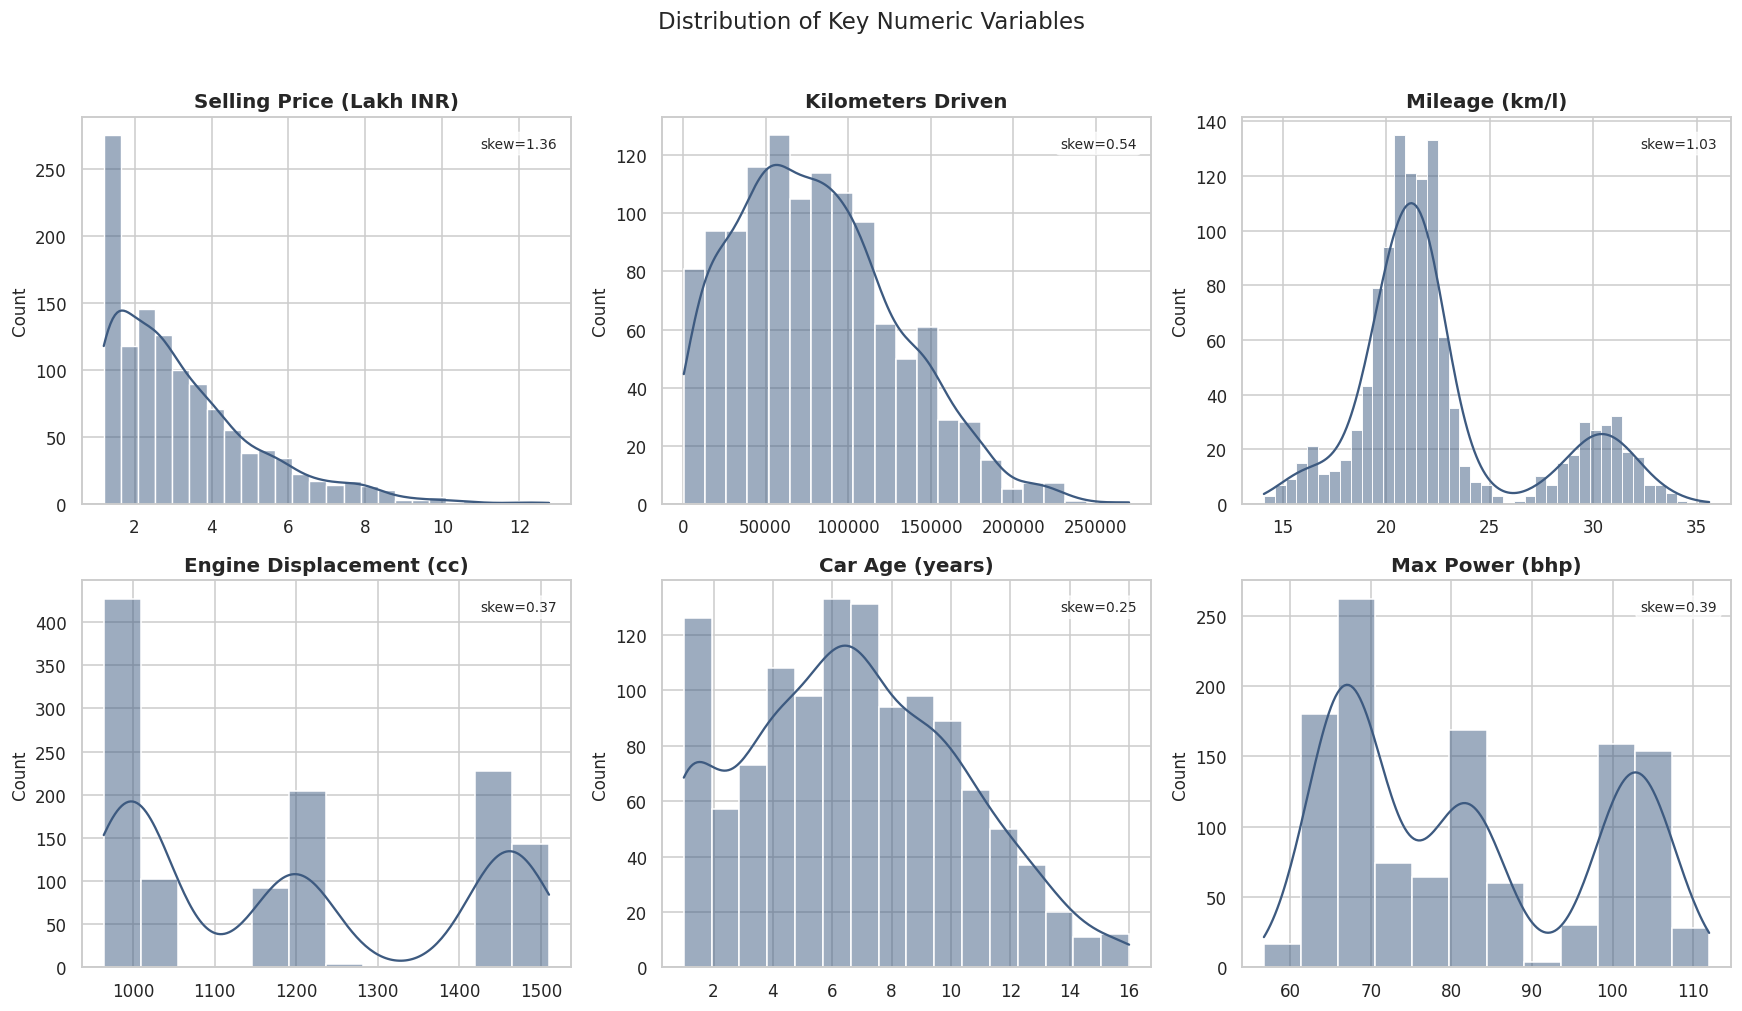

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
num_vars = [
    ("selling_price_lakh", "Selling Price (Lakh INR)"),
    ("km_driven", "Kilometers Driven"),
    ("mileage_kmpl", "Mileage (km/l)"),
    ("engine_cc", "Engine Displacement (cc)"),
    ("car_age", "Car Age (years)"),
    ("max_power_bhp", "Max Power (bhp)"),
]

for ax, (col, label) in zip(axes.flat, num_vars):
    sns.histplot(df_clean[col], kde=True, ax=ax, color="#3d5a80")
    ax.set_title(label)
    ax.set_xlabel("")
    skew = df_clean[col].skew()
    ax.text(0.97, 0.92, f"skew={skew:.2f}", transform=ax.transAxes, ha="right", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

plt.suptitle("Distribution of Key Numeric Variables", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


**Reading the distributions:**
- `selling_price_lakh` is right-skewed: most Suzuki listings sit in the affordable
  entry/mid segment, with a long tail from premium models (Grand Vitara, Jimny, XL6).
- `km_driven` is also right-skewed, driven by a handful of higher-mileage, older cars.
- `mileage_kmpl` shows a **bimodal-ish spread**, reflecting the mix of Petrol and CNG
  variants (CNG cars report noticeably higher km/l).
- `car_age` roughly reflects the sampling window of the resale listings.


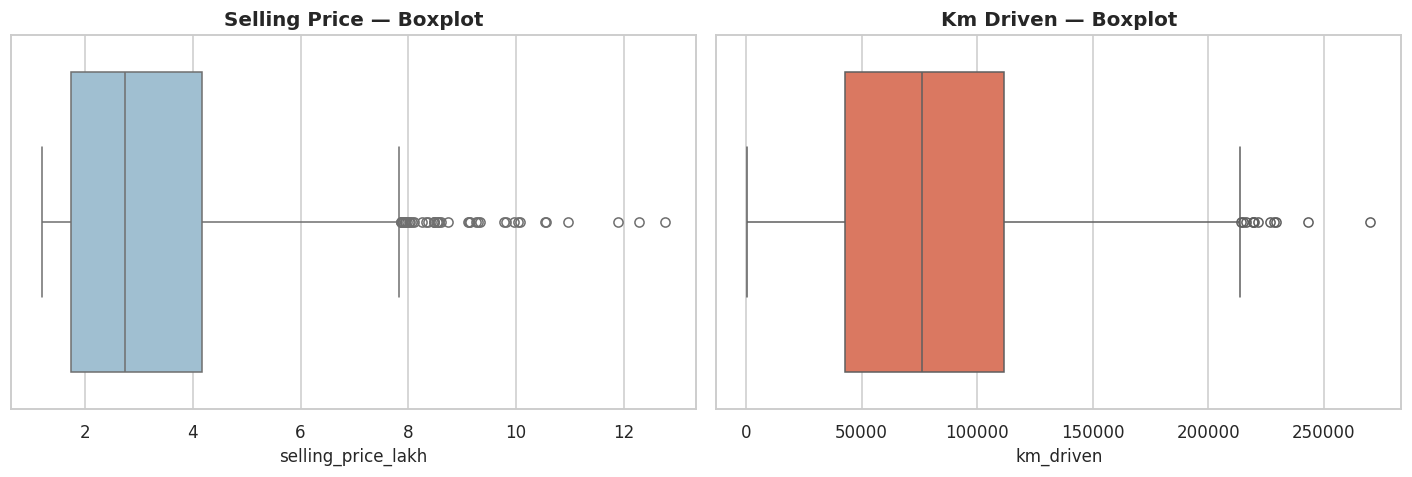

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(x=df_clean["selling_price_lakh"], ax=axes[0], color="#98c1d9")
axes[0].set_title("Selling Price — Boxplot")
sns.boxplot(x=df_clean["km_driven"], ax=axes[1], color="#ee6c4d")
axes[1].set_title("Km Driven — Boxplot")
plt.tight_layout()
plt.show()


## 8. Price Analysis

Here we examine how selling price relates to age, mileage driven, transmission, and
ownership history — the classic depreciation drivers in a used-car market.


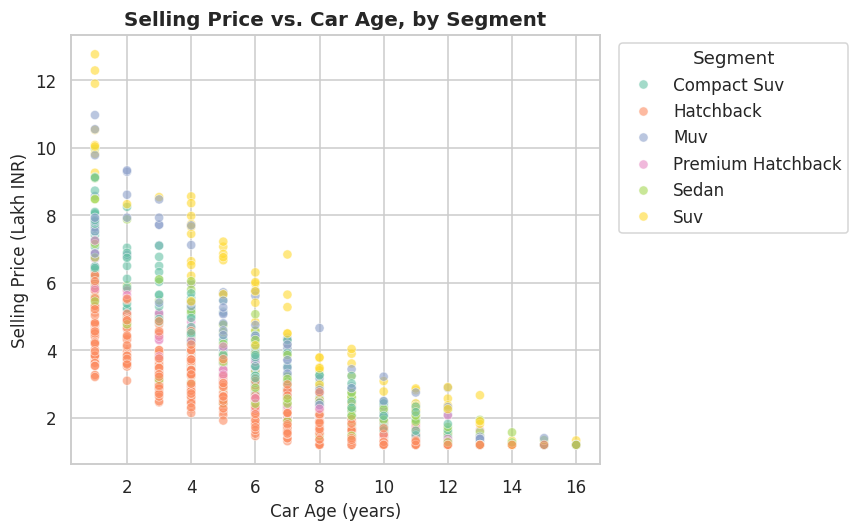

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df_clean, x="car_age", y="selling_price_lakh", hue="segment",
                 alpha=0.6, ax=ax, palette="Set2")
ax.set_title("Selling Price vs. Car Age, by Segment")
ax.set_xlabel("Car Age (years)")
ax.set_ylabel("Selling Price (Lakh INR)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Segment")
plt.tight_layout()
plt.show()


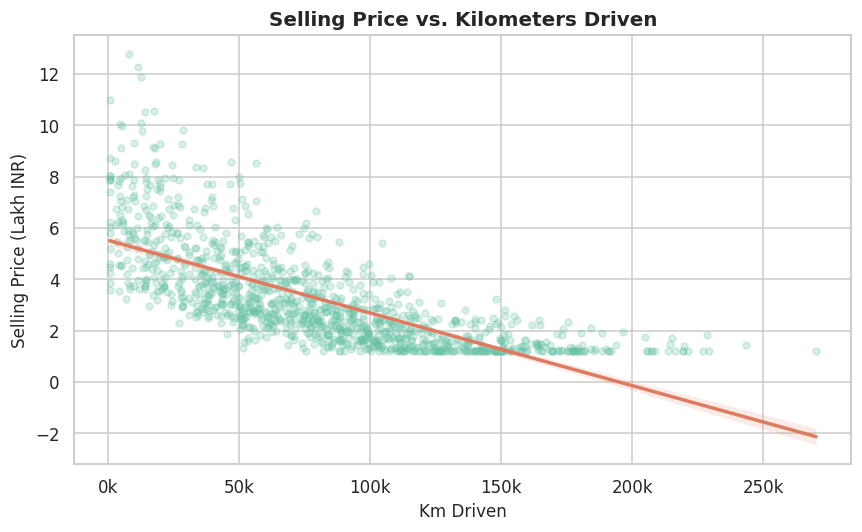

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=df_clean, x="km_driven", y="selling_price_lakh",
            scatter_kws={"alpha": 0.25, "s": 20}, line_kws={"color": "#e07a5f"}, ax=ax)
ax.set_title("Selling Price vs. Kilometers Driven")
ax.set_xlabel("Km Driven")
ax.set_ylabel("Selling Price (Lakh INR)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
plt.tight_layout()
plt.show()


/tmp/ipykernel_599/3120196551.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="transmission", y="selling_price_lakh", ax=axes[0], palette="pastel")
/tmp/ipykernel_599/3120196551.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="owner", y="selling_price_lakh", order=owner_order, ax=axes[1], palette="pastel")


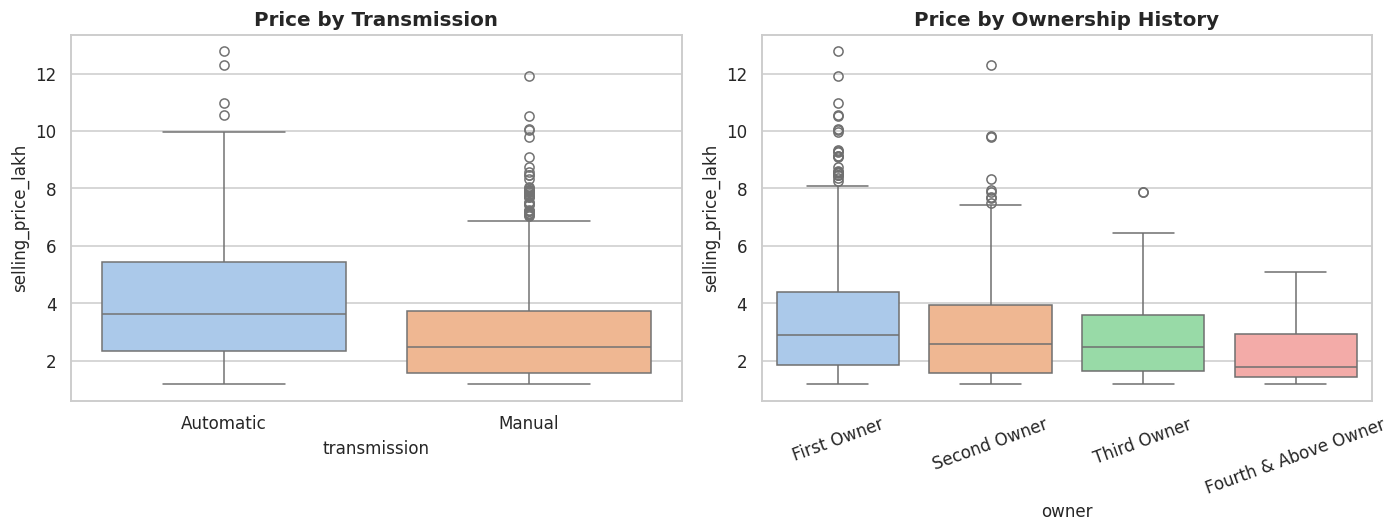

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_clean, x="transmission", y="selling_price_lakh", ax=axes[0], palette="pastel")
axes[0].set_title("Price by Transmission")

owner_order = ["First Owner", "Second Owner", "Third Owner", "Fourth & Above Owner"]
sns.boxplot(data=df_clean, x="owner", y="selling_price_lakh", order=owner_order, ax=axes[1], palette="pastel")
axes[1].set_title("Price by Ownership History")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


In [20]:
avg_price_by_owner = df_clean.groupby("owner", observed=True)["selling_price_lakh"].mean().reindex(owner_order)
avg_price_by_trans = df_clean.groupby("transmission", observed=True)["selling_price_lakh"].mean()

print("Average price by ownership:")
print(avg_price_by_owner.round(2))
print("\nAverage price by transmission:")
print(avg_price_by_trans.round(2))


Average price by ownership:
owner
First Owner             3.44
Second Owner            3.04
Third Owner             2.87
Fourth & Above Owner    2.21
Name: selling_price_lakh, dtype: float64

Average price by transmission:
transmission
Automatic    4.05
Manual       2.93
Name: selling_price_lakh, dtype: float64


**Key observations:**
- Price falls steadily with **car age**, consistent with a standard depreciation curve.
- Higher **km_driven** is associated with lower prices, though the relationship is noisier
  than age alone — usage intensity matters, but so does condition/model.
- **Automatic-transmission** Suzuki cars command a clear price premium over manual
  variants of comparable age, reflecting AMT/AT models being relatively newer and
  higher-trim.
- Price declines monotonically as we move from **First Owner** to **Fourth & Above
  Owner**, confirming ownership history as a strong (and easily verifiable) price signal.


## 9. Model Comparison

Suzuki's line-up spans hatchbacks, sedans, MUVs, and SUVs. We compare listing volume,
average price, and price spread across models.


/tmp/ipykernel_599/768698561.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_counts.values, y=model_counts.index, ax=ax, palette="viridis")


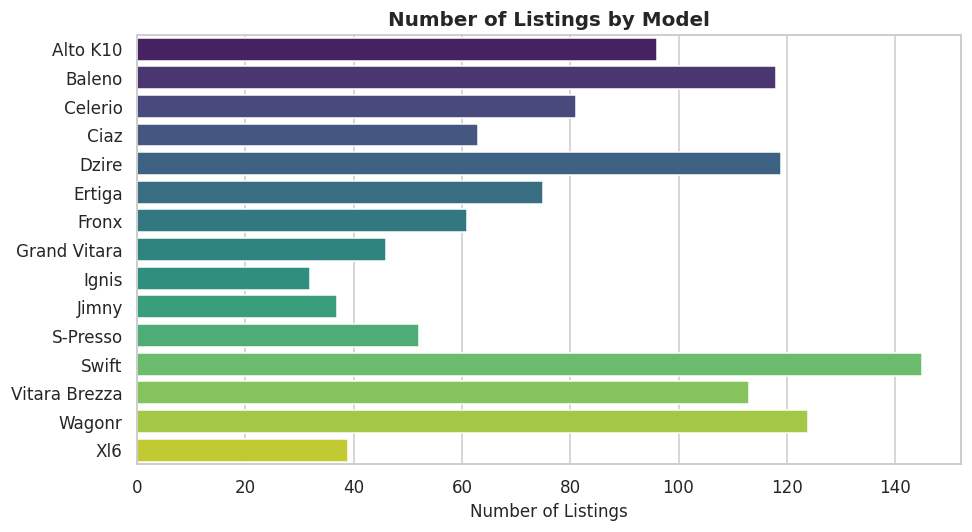

In [21]:
model_counts = df_clean["model"].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=model_counts.values, y=model_counts.index, ax=ax, palette="viridis")
ax.set_title("Number of Listings by Model")
ax.set_xlabel("Number of Listings")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


/tmp/ipykernel_599/1069538384.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="selling_price_lakh", y="model", order=order_by_price, ax=ax, palette="coolwarm")


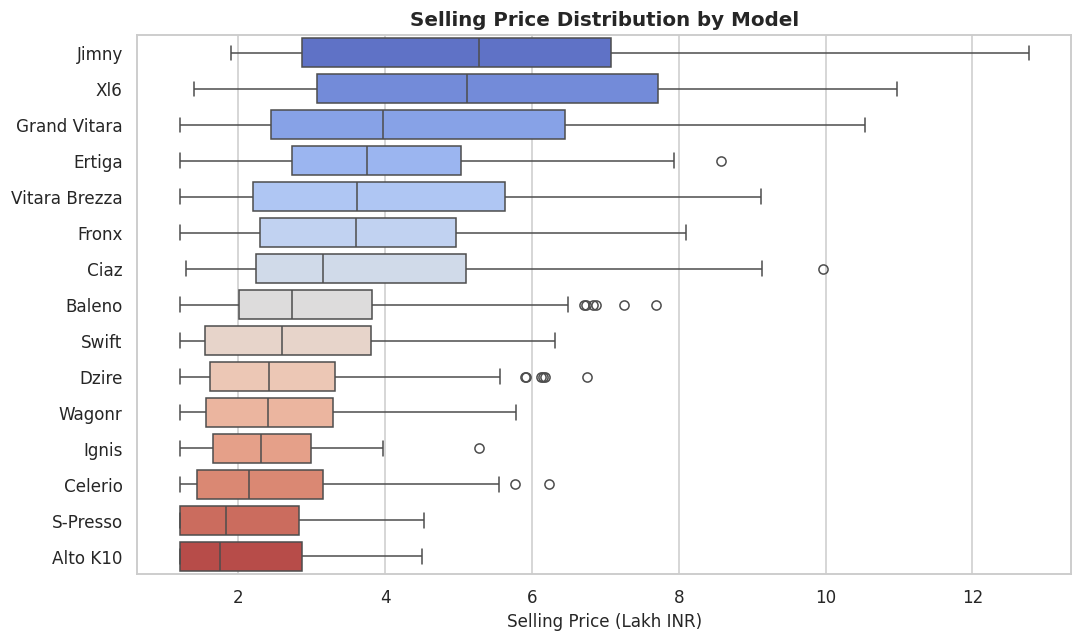

In [22]:
order_by_price = df_clean.groupby("model", observed=True)["selling_price_lakh"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_clean, x="selling_price_lakh", y="model", order=order_by_price, ax=ax, palette="coolwarm")
ax.set_title("Selling Price Distribution by Model")
ax.set_xlabel("Selling Price (Lakh INR)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


In [23]:
model_summary = df_clean.groupby("model", observed=True).agg(
    listings=("model", "count"),
    avg_price=("selling_price_lakh", "mean"),
    median_price=("selling_price_lakh", "median"),
    avg_km_driven=("km_driven", "mean"),
    avg_age=("car_age", "mean"),
).round(2).sort_values("avg_price", ascending=False)

model_summary


,listings,avg_price,median_price,avg_km_driven,avg_age
model,,,,,
Xl6,39,5.54,5.11,71563.38,6.00
Jimny,37,5.45,5.28,88531.89,7.24
Grand Vitara,46,4.68,3.97,90292.48,7.22
Ertiga,75,4.05,3.75,78924.83,6.41
Vitara Brezza,113,4.02,3.62,80480.52,6.48
Ciaz,63,3.89,3.15,91321.06,7.21
Fronx,61,3.84,3.60,71886.64,6.21
Baleno,118,3.13,2.73,79598.78,6.62
Swift,145,2.90,2.60,77793.83,6.71


**Key observations:**
- **Swift** and **Dzire** dominate listing volume — unsurprising, as they are Suzuki's
  best-selling nameplates historically.
- Premium/SUV nameplates (**Grand Vitara, Jimny, XL6, Ciaz**) command the highest
  median resale prices but appear far less frequently, reflecting lower sales volumes
  and/or more recent launches.
- Entry hatchbacks (**Alto K10, S-Presso, Celerio**) anchor the affordable end of the
  market, as expected.


## 10. Year Trends

How has the Suzuki listing mix — segment popularity, fuel type, transmission — evolved
across manufacturing years?


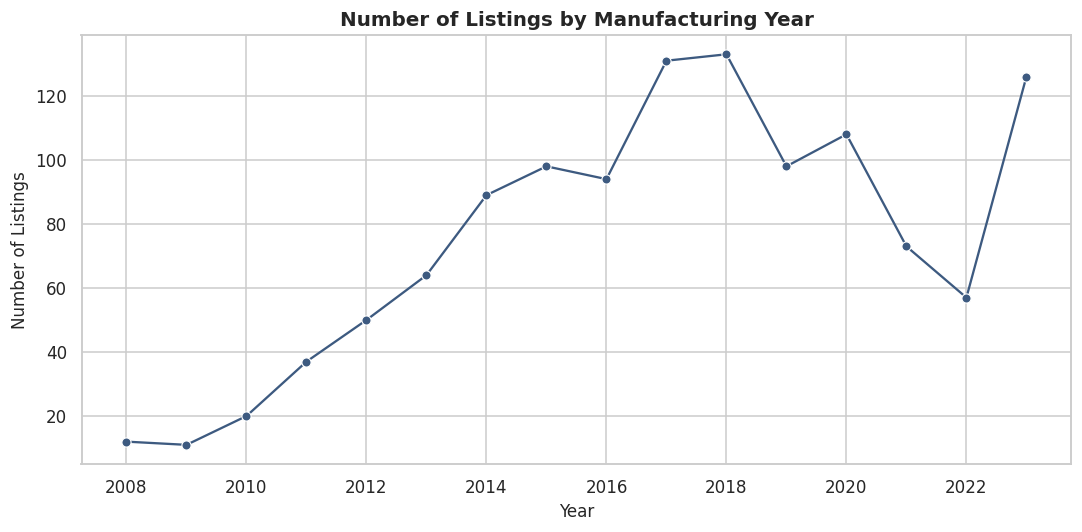

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
year_counts = df_clean["year"].value_counts().sort_index()
sns.lineplot(x=year_counts.index, y=year_counts.values, marker="o", ax=ax, color="#3d5a80")
ax.set_title("Number of Listings by Manufacturing Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Listings")
plt.tight_layout()
plt.show()


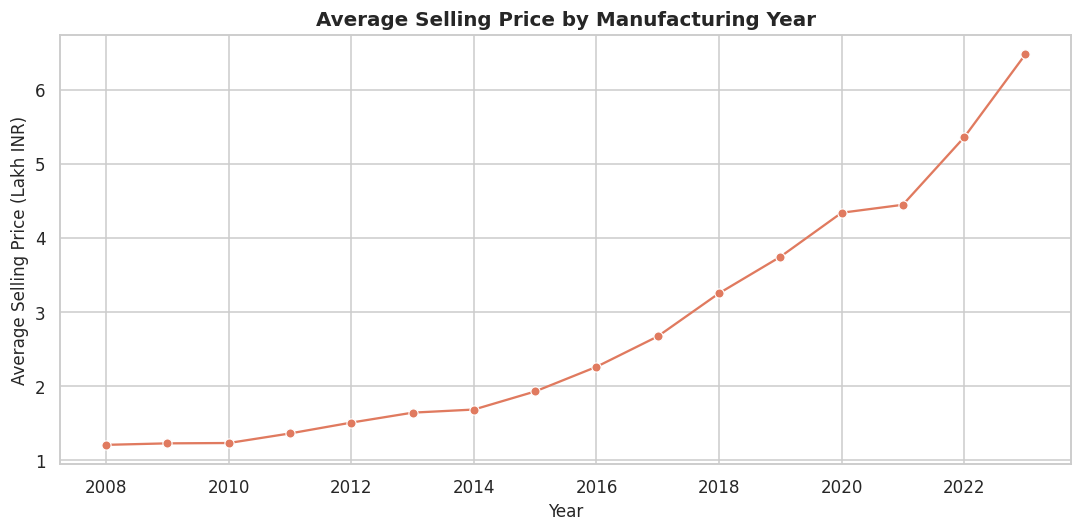

In [25]:
year_price = df_clean.groupby("year", observed=True)["selling_price_lakh"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(x=year_price.index, y=year_price.values, marker="o", ax=ax, color="#e07a5f")
ax.set_title("Average Selling Price by Manufacturing Year")
ax.set_xlabel("Year")
ax.set_ylabel("Average Selling Price (Lakh INR)")
plt.tight_layout()
plt.show()


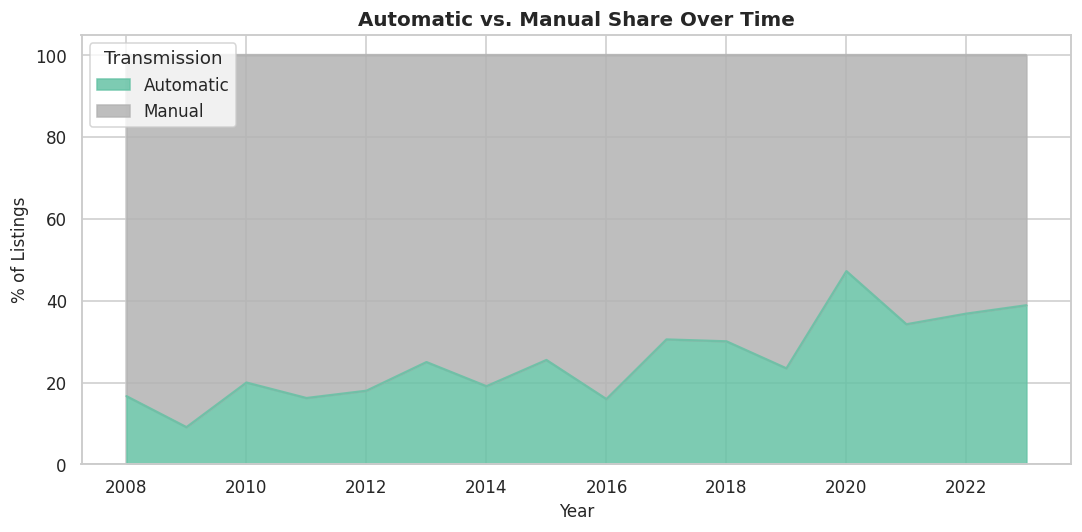

In [26]:
trans_by_year = pd.crosstab(df_clean["year"], df_clean["transmission"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(10, 5))
trans_by_year.plot(kind="area", stacked=True, ax=ax, colormap="Set2", alpha=0.85)
ax.set_title("Automatic vs. Manual Share Over Time")
ax.set_ylabel("% of Listings")
ax.set_xlabel("Year")
ax.legend(title="Transmission", loc="upper left")
plt.tight_layout()
plt.show()


**Key observations:**
- Average selling price rises with manufacturing year, mostly reflecting **lower age**
  (less depreciation) for newer listings rather than a change in original sticker price.
- The share of **automatic transmission** listings grows steadily for more recent
  manufacturing years — consistent with Suzuki's real-world push toward AMT/CVT/torque-converter
  options across its range from the mid-2010s onward.


## 11. Mileage Analysis

"Mileage" here refers to fuel efficiency (km/l) — a key purchase driver in the
budget/compact segment Suzuki competes in.


/tmp/ipykernel_599/240878029.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="fuel", y="mileage_kmpl", ax=ax, palette="Set2")


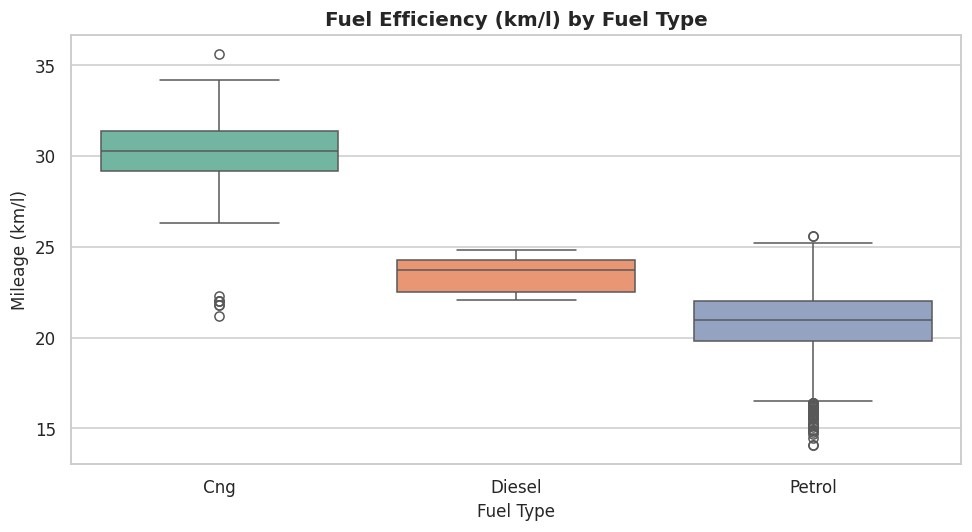

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df_clean, x="fuel", y="mileage_kmpl", ax=ax, palette="Set2")
ax.set_title("Fuel Efficiency (km/l) by Fuel Type")
ax.set_xlabel("Fuel Type")
ax.set_ylabel("Mileage (km/l)")
plt.tight_layout()
plt.show()


/tmp/ipykernel_599/321515275.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, y="model", x="mileage_kmpl", order=mileage_order, ax=ax, palette="crest", errorbar=None)


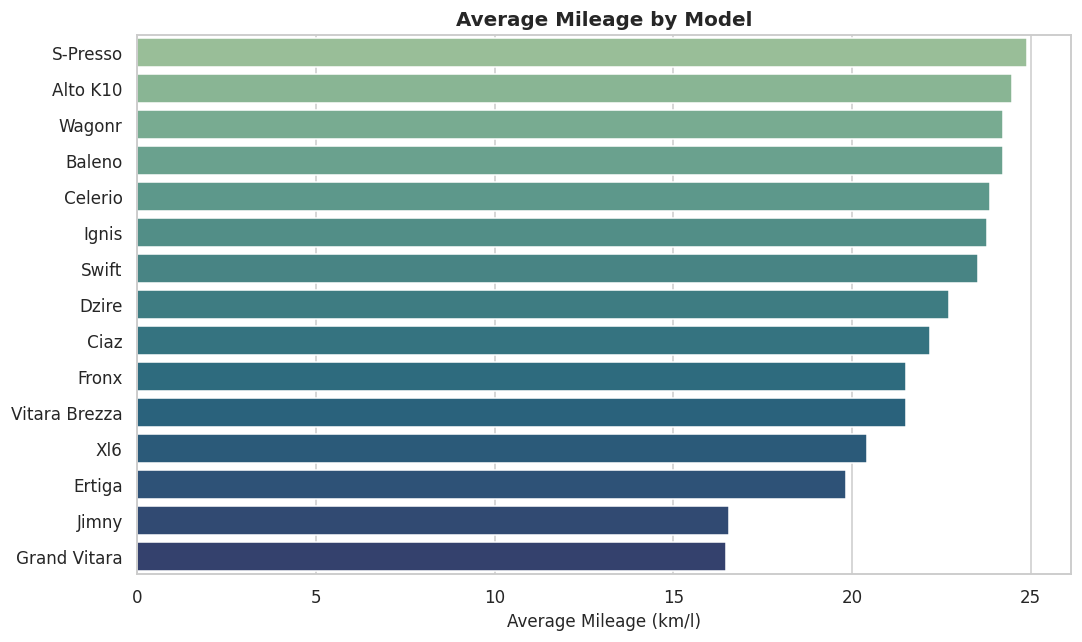

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
mileage_order = df_clean.groupby("model", observed=True)["mileage_kmpl"].mean().sort_values(ascending=False).index
sns.barplot(data=df_clean, y="model", x="mileage_kmpl", order=mileage_order, ax=ax, palette="crest", errorbar=None)
ax.set_title("Average Mileage by Model")
ax.set_xlabel("Average Mileage (km/l)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


In [29]:
corr_mileage_km, p_val = stats.pearsonr(df_clean["km_driven"], df_clean["mileage_kmpl"])
print(f"Correlation between km_driven and mileage_kmpl: r = {corr_mileage_km:.3f} (p = {p_val:.3g})")


Correlation between km_driven and mileage_kmpl: r = 0.010 (p = 0.727)


**Key observations:**
- **CNG variants** report meaningfully higher km/l than petrol counterparts, and diesel
  (limited to MUV/SUV models here) sits in between petrol and CNG.
- Compact hatchbacks (Celerio, WagonR, S-Presso, Alto K10) lead average mileage, in
  line with their smaller, lighter platforms — while SUVs like Grand Vitara and Jimny
  trail, as expected from larger engines and curb weight.
- `km_driven` and `mileage_kmpl` show a weak/negligible correlation, meaning fuel
  efficiency is primarily a function of model/fuel-type, not usage.


## 12. Fuel Type Analysis


/tmp/ipykernel_599/2813585377.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="fuel", y="selling_price_lakh", ax=axes[1], palette="Set2")


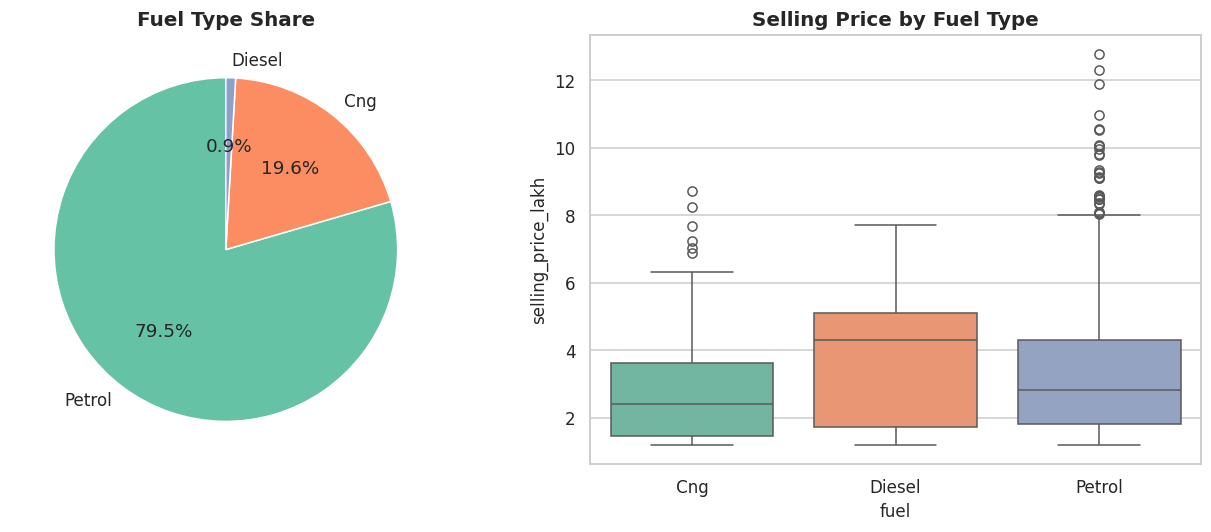

In [30]:
fuel_counts = df_clean["fuel"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(fuel_counts.values, labels=fuel_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("Set2"), startangle=90)
axes[0].set_title("Fuel Type Share")

sns.boxplot(data=df_clean, x="fuel", y="selling_price_lakh", ax=axes[1], palette="Set2")
axes[1].set_title("Selling Price by Fuel Type")

plt.tight_layout()
plt.show()


In [31]:
fuel_segment = pd.crosstab(df_clean["segment"], df_clean["fuel"])
fuel_segment


fuel,Cng,Diesel,Petrol
segment,,,
Compact Suv,20,0,154
Hatchback,155,0,375
Muv,0,11,103
Premium Hatchback,29,0,89
Sedan,31,0,151
Suv,0,0,83


**Key observations:**
- **Petrol** dominates the Suzuki resale mix, consistent with Suzuki's small-car,
  petrol-first strategy (particularly relevant in the Indian market it leads).
- **CNG** variants form a meaningful minority, concentrated in hatchbacks and sedans
  where factory-fitted CNG options are common (Swift, WagonR, Dzire, Celerio).
- **Diesel** appears only in a small number of MUV listings, reflecting Suzuki's broader
  industry shift away from diesel engines in small cars.


## 13. Transmission Analysis


/tmp/ipykernel_599/2717738384.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x="transmission", y="selling_price_lakh", ax=axes[1], palette=["#98c1d9", "#ee6c4d"])


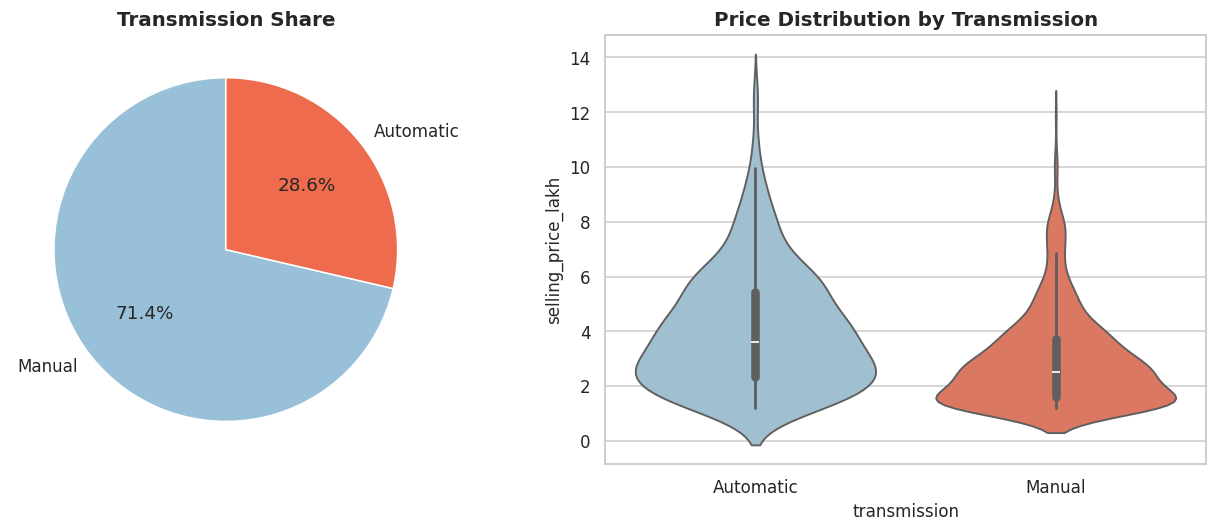

In [32]:
trans_counts = df_clean["transmission"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(trans_counts.values, labels=trans_counts.index, autopct="%1.1f%%",
            colors=["#98c1d9", "#ee6c4d"], startangle=90)
axes[0].set_title("Transmission Share")

sns.violinplot(data=df_clean, x="transmission", y="selling_price_lakh", ax=axes[1], palette=["#98c1d9", "#ee6c4d"])
axes[1].set_title("Price Distribution by Transmission")

plt.tight_layout()
plt.show()


In [33]:
trans_by_segment = pd.crosstab(df_clean["segment"], df_clean["transmission"], normalize="index") * 100
trans_by_segment.round(1)


transmission,Automatic,Manual
segment,,
Compact Suv,40.2,59.8
Hatchback,24.0,76.0
Muv,39.5,60.5
Premium Hatchback,22.0,78.0
Sedan,22.5,77.5
Suv,42.2,57.8


**Key observations:**
- **Manual** transmissions still make up the majority of listings, reflecting Suzuki's
  cost-conscious, manual-first heritage in entry segments.
- **Automatic** share is highest in **Compact SUV / SUV / MUV** segments, where buyers
  are more willing to pay for the convenience premium.
- Automatic listings show a noticeably higher median price, as seen earlier — both a
  trim-level effect and an age effect (automatics skew newer).


## 14. Correlation Analysis


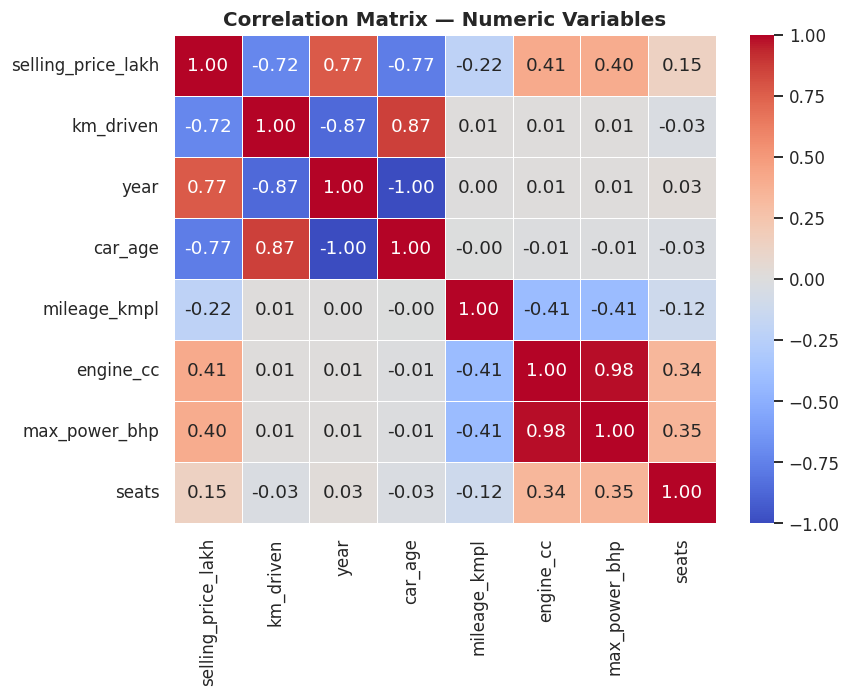

In [34]:
num_cols = ["selling_price_lakh", "km_driven", "year", "car_age", "mileage_kmpl", "engine_cc", "max_power_bhp", "seats"]
corr = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, linewidths=0.5)
ax.set_title("Correlation Matrix — Numeric Variables")
plt.tight_layout()
plt.show()


In [35]:
price_corr = corr["selling_price_lakh"].drop("selling_price_lakh").sort_values(key=abs, ascending=False)
price_corr


car_age         -0.771342
year             0.771342
km_driven       -0.720416
engine_cc        0.409254
max_power_bhp    0.399835
mileage_kmpl    -0.215680
seats            0.145881
Name: selling_price_lakh, dtype: float64

**Key observations:**
- `car_age` (and inversely `year`) is the **strongest driver** of selling price —
  confirming depreciation as the dominant force in this market, as is typical for used cars.
- `max_power_bhp` and `engine_cc` correlate positively with price, since higher-segment
  Suzuki models (SUV/MUV) both cost more and have larger engines.
- `km_driven` correlates negatively with price but more weakly than age — two cars of the
  same age can have very different usage histories, adding noise to this relationship.
- `mileage_kmpl` shows a mild negative correlation with price, mostly because the most
  fuel-efficient cars tend to be the cheapest entry hatchbacks, not because efficiency
  itself reduces value.


## 15. Business Insights

Bringing the sections above together, from the perspective of a dealership, resale
marketplace, or Suzuki-focused analyst:

1. **Depreciation is predictable and age-driven.** Since `car_age` is by far the
   strongest price correlate, a simple age-based pricing baseline (adjusted for
   ownership count and transmission) would already explain most of the price variance —
   useful as a first-pass valuation model before layering in condition and market demand.

2. **Ownership history is an easy, high-value pricing lever.** The clear price gap
   between First Owner and later-owner cars suggests marketplaces should surface
   ownership count prominently, and dealers should prioritize sourcing low-owner-count
   stock, which resells at a premium.

3. **Automatic variants are underrepresented but command a premium**, particularly in
   the Compact SUV/SUV/MUV segments. This signals an opportunity: dealers stocking
   automatic Vitara Brezza, Fronx, or Ertiga units may see faster turnover and better
   margins as buyer preference shifts toward convenience.

4. **CNG variants extend Suzuki's fuel-efficiency edge.** Given Suzuki's strong CNG
   penetration in hatchbacks/sedans, marketing these variants on running-cost savings
   (not just sticker price) is a differentiator versus competitors with weaker CNG
   line-ups.

5. **Volume vs. margin trade-off across the model range.** Swift/Dzire dominate volume
   (useful for turnover-driven strategies), while Grand Vitara/Jimny/XL6 offer higher
   per-unit margins but slower turnover — a portfolio-balancing consideration for
   inventory-constrained dealers.

6. **km_driven alone is an incomplete price signal.** Because usage intensity varies so
   much between cars of the same age, valuation models (and buyers) should treat high
   mileage as a secondary adjustment on top of an age-based baseline, not a primary driver.


## 16. Final Conclusions

This EDA of the Suzuki used-car segment shows a market shaped primarily by **age-driven
depreciation**, with **ownership history** and **transmission type** as secondary but
meaningful price levers. Suzuki's product mix — petrol/CNG-heavy, hatchback- and
sedan-led, with a growing but still-niche SUV/MUV presence — is clearly visible in the
data: volume concentrates in affordable, fuel-efficient models (Swift, Dzire, WagonR),
while price ceilings are set by the newer SUV/MUV additions (Grand Vitara, Jimny, XL6).

**Limitations:** this notebook uses a *synthetically generated* dataset designed to
mirror realistic used-car market relationships, not scraped real-world listings. The
qualitative patterns (depreciation curves, CNG mileage advantage, automatic-transmission
premium, model-segment pricing hierarchy) are grounded in how these markets actually
behave, but exact figures should not be treated as real market data. Extending this
project with genuine Suzuki listings (e.g. from a marketplace export or a Kaggle
dataset filtered to Suzuki/Maruti Suzuki) would allow the same pipeline to produce
production-grade insights.

**Suggested next steps:**
- Fit a baseline price-prediction model (e.g. gradient boosting) using `car_age`,
  `km_driven`, `transmission`, `owner`, and `segment` as features, and compare against
  the simple age-based heuristic implied by the correlation analysis.
- Incorporate real regional pricing data if targeting a specific resale market.
- Track listing counts and price trends over time (e.g. monthly) if working with a
  live marketplace feed, rather than a static snapshot.


---
### Appendix: Data Generation Logic

For transparency, the synthetic dataset used in this notebook was generated with the
following logic (model-specific base prices, segment-based mileage/engine profiles, an
exponential depreciation curve by age, and a `km_driven`/ownership/transmission price
adjustment), then had realistic messiness (duplicates, missing values, inconsistent
casing, string-embedded units, and outliers) injected on top — see `generate_data.py`
in the project files for the full, reproducible script.
